## Student Performance Indicator


### 1) Problem statement
- This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.


### 2) Data Collection
- Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
- The data consists of 8 column and 1000 rows.

### 2.1 Import Data and Required Packages
####  Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [25]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

#### Import the CSV Data as Pandas DataFrame

In [26]:
df = pd.read_csv(r'/content/stud.csv')

#### Show Top 5 Records

In [27]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### Shape of the dataset

In [28]:
df.shape

(1000, 8)

### 2.2 Dataset information

- gender : sex of students  -> (Male/female)
- race/ethnicity : ethnicity of students -> (Group A, B,C, D,E)
- parental level of education : parents' final education ->(bachelor's degree,some college,master's degree,associate's degree,high school)
- lunch : having lunch before test (standard or free/reduced)
- test preparation course : complete or not complete before test
- math score
- reading score
- writing score

### 3. Data Checks to perform

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

### 3.1 Check Missing values

In [29]:
df.isna().sum()

,0
gender,0
race_ethnicity,0
parental_level_of_education,0
lunch,0
test_preparation_course,0
math_score,0
reading_score,0
writing_score,0


#### There are no missing values in the data set

### 3.2 Check Duplicates

In [30]:
df.duplicated().sum()

np.int64(0)

#### There are no duplicates  values in the data set

### 3.3 Check data types

In [31]:
# Check Null and Dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


### 3.4 Checking the number of unique values of each column

In [32]:
df.nunique()

,0
gender,2
race_ethnicity,5
parental_level_of_education,6
lunch,2
test_preparation_course,2
math_score,81
reading_score,72
writing_score,77


### 3.5 Check statistics of data set

In [33]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


#### Insight
- From above description of numerical data, all means are very close to each other - between 66 and 68.05;
- All standard deviations are also close - between 14.6 and 15.19;
- While there is a minimum score  0 for math, for writing minimum is much higher = 10 and for reading myet higher = 17

### 3.7 Exploring Data

In [34]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [35]:
print("Categories in 'gender' variable:     ",end=" " )
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable:  ",end=" ")
print(df['race_ethnicity'].unique())

print("Categories in'parental level of education' variable:",end=" " )
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' variable:     ",end=" " )
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable:     ",end=" " )
print(df['test_preparation_course'].unique())

Categories in 'gender' variable:      ['female' 'male']
Categories in 'race_ethnicity' variable:   ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in'parental level of education' variable: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable:      ['standard' 'free/reduced']
Categories in 'test preparation course' variable:      ['none' 'completed']


In [36]:
# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 3 numerical features : ['math_score', 'reading_score', 'writing_score']

We have 5 categorical features : ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [37]:
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


### 3.8 Adding columns for "Total Score" and "Average"

In [38]:
df['total score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average'] = df['total score']/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [39]:
reading_full = df[df['reading_score'] == 100]['average'].count()
writing_full = df[df['writing_score'] == 100]['average'].count()
math_full = df[df['math_score'] == 100]['average'].count()

print(f'Number of students with full marks in Maths: {math_full}')
print(f'Number of students with full marks in Writing: {writing_full}')
print(f'Number of students with full marks in Reading: {reading_full}')

Number of students with full marks in Maths: 7
Number of students with full marks in Writing: 14
Number of students with full marks in Reading: 17


In [40]:
reading_less_20 = df[df['reading_score'] <= 20]['average'].count()
writing_less_20 = df[df['writing_score'] <= 20]['average'].count()
math_less_20 = df[df['math_score'] <= 20]['average'].count()

print(f'Number of students with less than 20 marks in Maths: {math_less_20}')
print(f'Number of students with less than 20 marks in Writing: {writing_less_20}')
print(f'Number of students with less than 20 marks in Reading: {reading_less_20}')

Number of students with less than 20 marks in Maths: 4
Number of students with less than 20 marks in Writing: 3
Number of students with less than 20 marks in Reading: 1


#####  Insights
 - From above values we get students have performed the worst in Maths
 - Best performance is in reading section

### 4. Exploring Data ( Visualization )
#### 4.1 Visualize average score distribution to make some conclusion.
- Histogram
- Kernel Distribution Function (KDE)

#### 4.1.1 Histogram & KDE

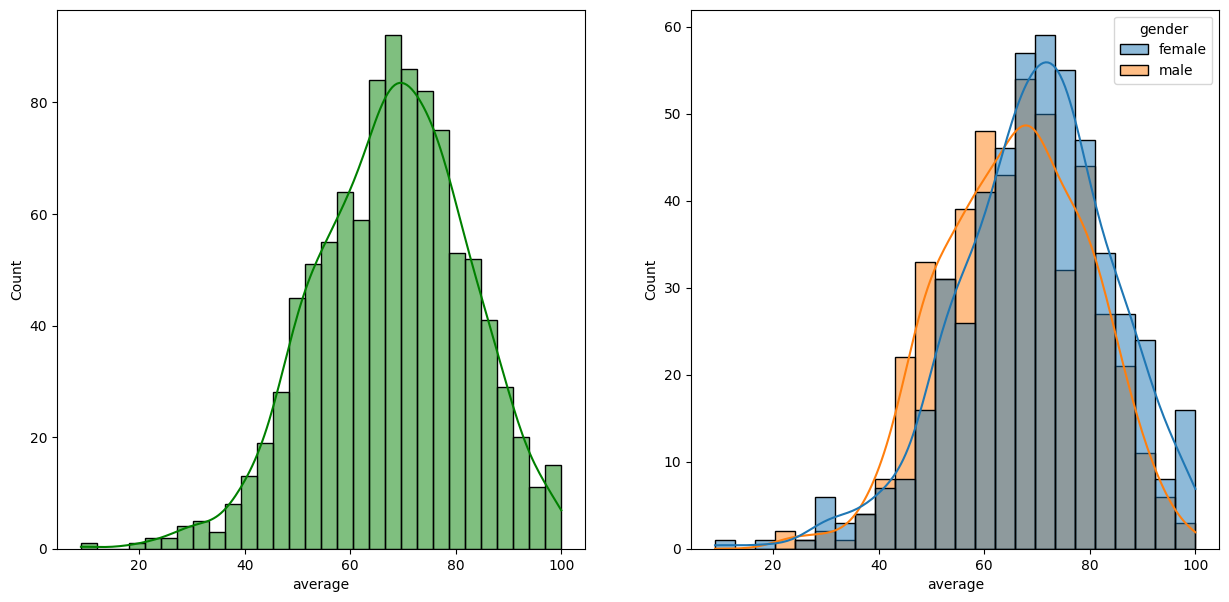

In [41]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='average',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='average',kde=True,hue='gender')
plt.show()

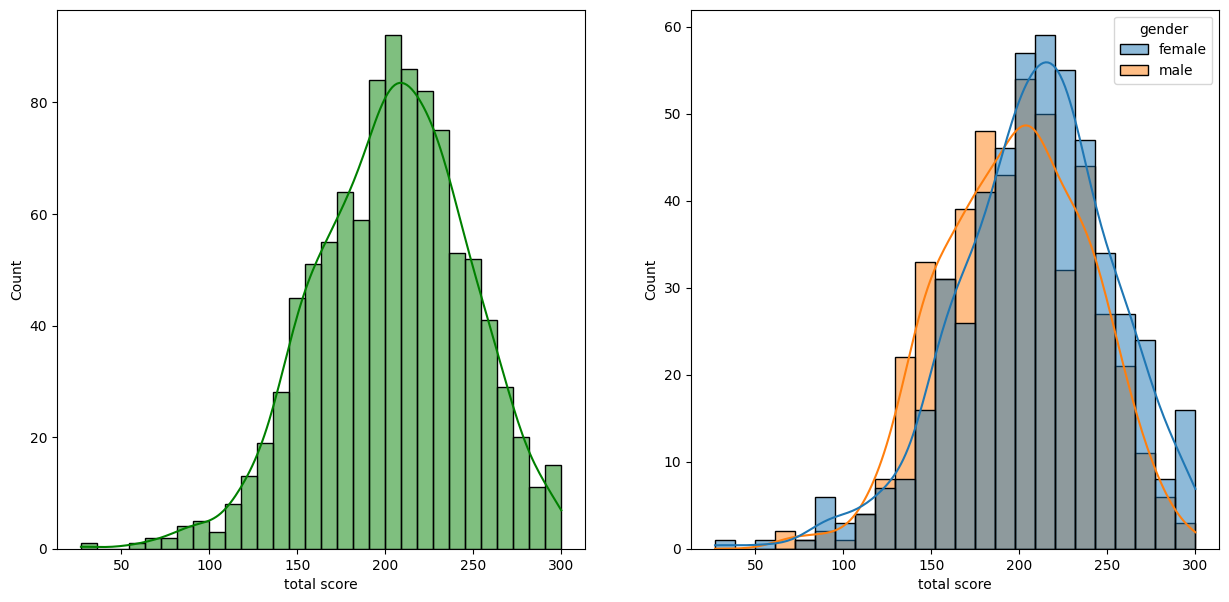

In [42]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='total score',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='total score',kde=True,hue='gender')
plt.show()

#####  Insights
- Female students tend to perform well then male students.

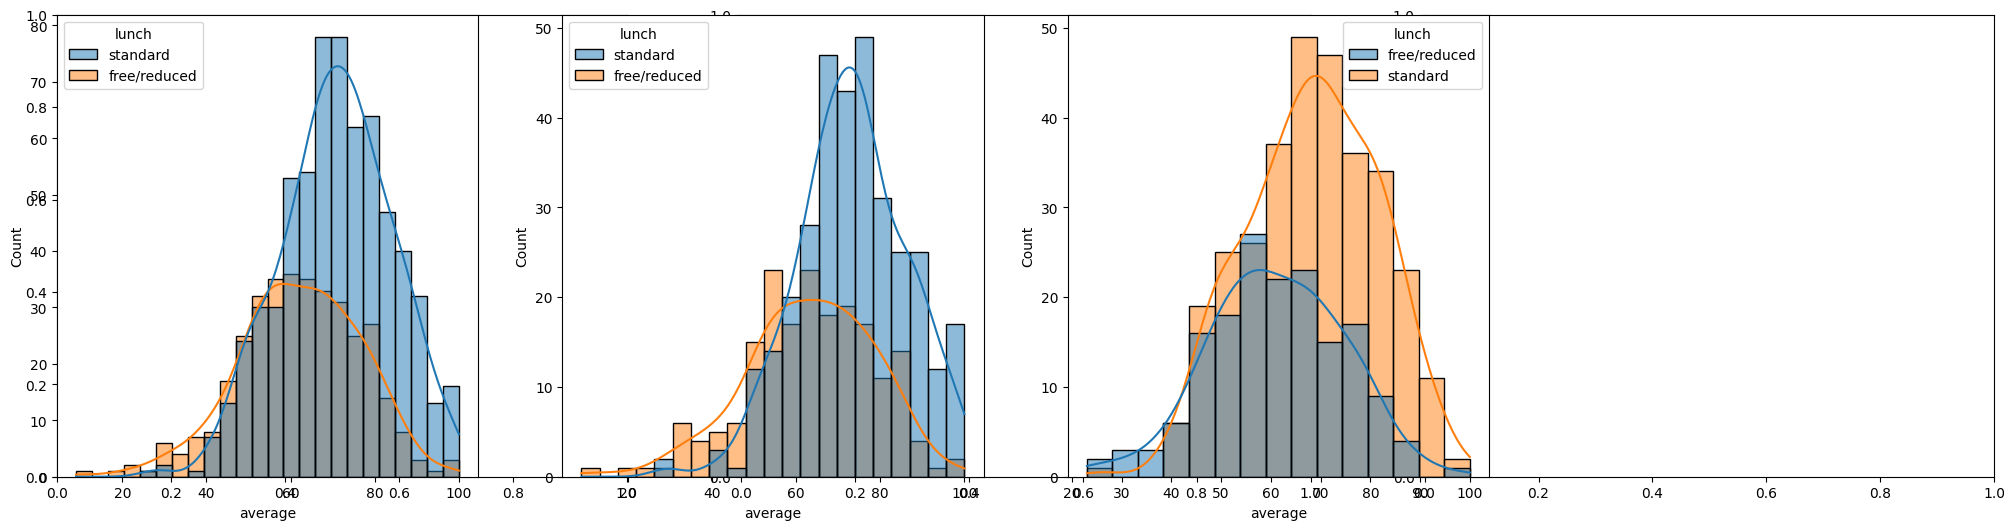

In [43]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df,x='average',kde=True,hue='lunch')
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='lunch')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='lunch')
plt.show()

#####  Insights
- Standard lunch helps perform well in exams.
- Standard lunch helps perform well in exams be it a male or a female.

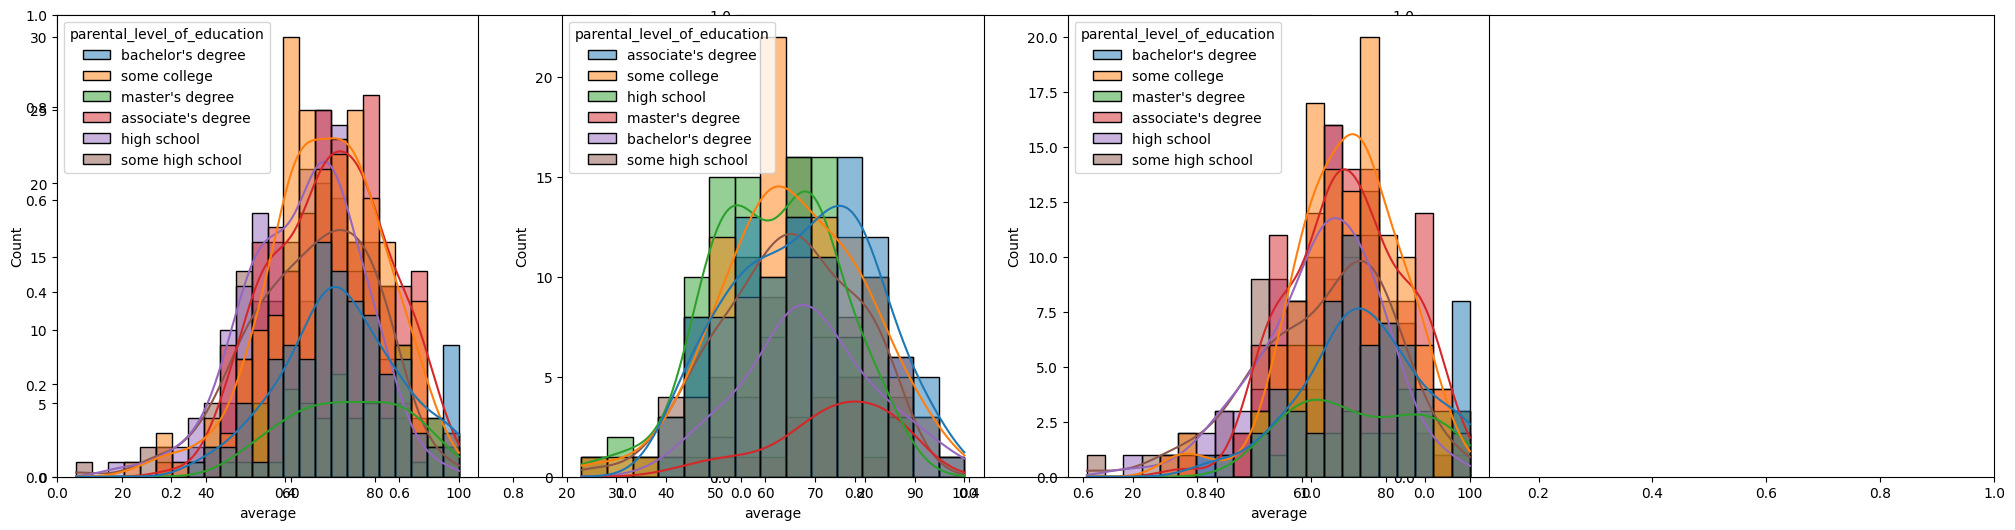

In [44]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
ax =sns.histplot(data=df,x='average',kde=True,hue='parental_level_of_education')
plt.subplot(142)
ax =sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='parental_level_of_education')
plt.subplot(143)
ax =sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='parental_level_of_education')
plt.show()

#####  Insights
- In general parent's education don't help student perform well in exam.
- 2nd plot shows that parent's whose education is of associate's degree or master's degree their male child tend to perform well in exam
- 3rd plot we can see there is no effect of parent's education on female students.

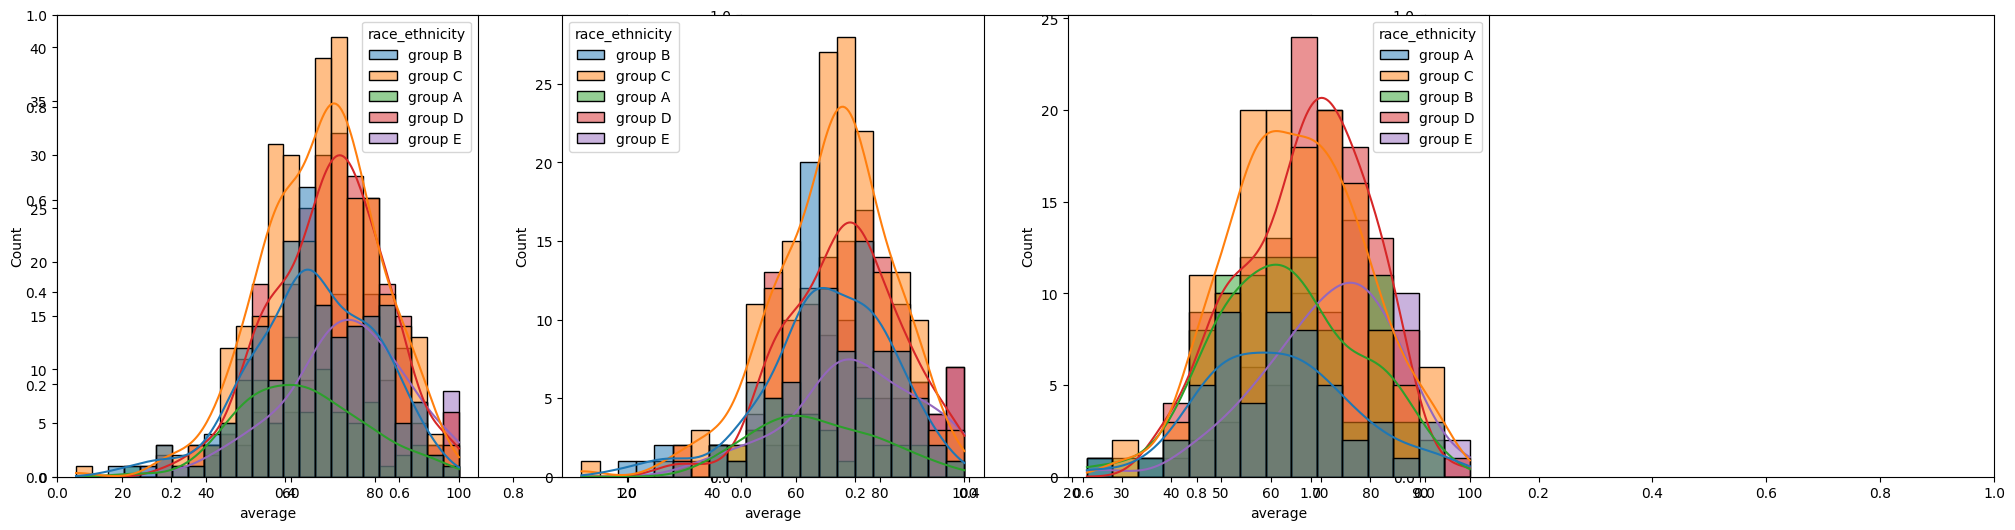

In [46]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
ax =sns.histplot(data=df,x='average',kde=True,hue='race_ethnicity')
plt.subplot(142)
ax =sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='race_ethnicity')
plt.subplot(143)
ax =sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='race_ethnicity')
plt.show()

#####  Insights
- Students of group A and group B tends to perform poorly in exam.
- Students of group A and group B tends to perform poorly in exam irrespective of whether they are male or female

#### 4.2 Maximumum score of students in all three subjects

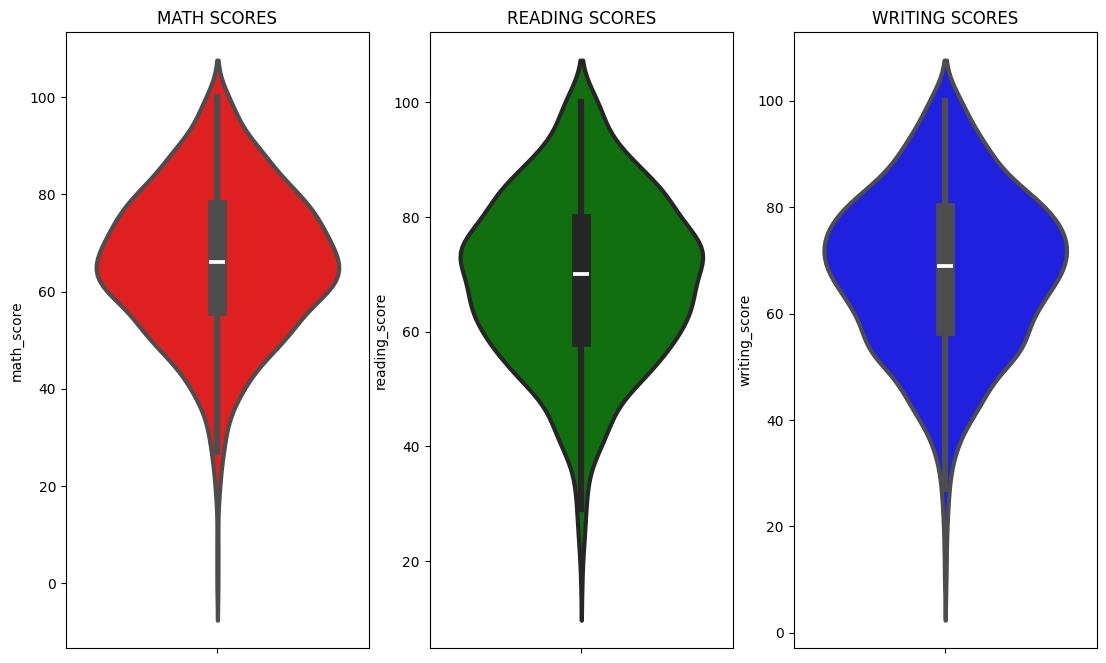

In [47]:
plt.figure(figsize=(18,8))
plt.subplot(1, 4, 1)
plt.title('MATH SCORES')
sns.violinplot(y='math_score',data=df,color='red',linewidth=3)
plt.subplot(1, 4, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading_score',data=df,color='green',linewidth=3)
plt.subplot(1, 4, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing_score',data=df,color='blue',linewidth=3)
plt.show()

#### Insights
- From the above three plots its clearly visible that most of the students score in between 60-80 in Maths whereas in reading and writing most of them score from 50-80

#### 4.3 Multivariate analysis using pieplot

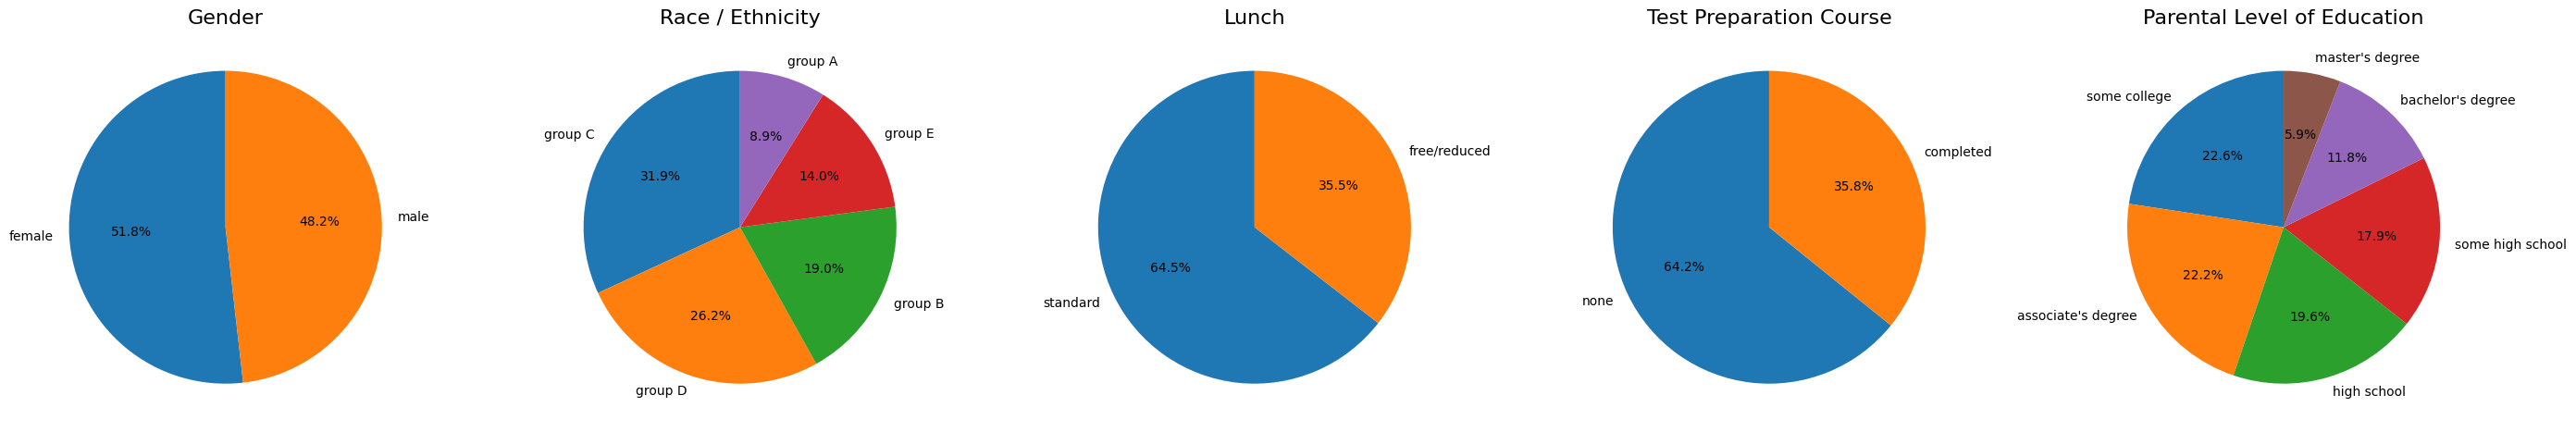

In [50]:
# Define columns to plot
columns = [
    'gender',
    'race_ethnicity',
    'lunch',
    'test_preparation_course',
    'parental_level_of_education'
]

titles = [
    'Gender',
    'Race / Ethnicity',
    'Lunch',
    'Test Preparation Course',
    'Parental Level of Education'
]

plt.figure(figsize=(28, 10))

for i, (col, title) in enumerate(zip(columns, titles), 1):
    plt.subplot(1, 5, i)
    counts = df[col].value_counts()

    plt.pie(
        counts.values,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=90
    )

    plt.title(title, fontsize=16)
    plt.axis('off')

plt.tight_layout()
plt.show()


#####  Insights
- Number of Male and Female students is almost equal
- Number students are greatest in Group C
- Number of students who have standard lunch are greater
- Number of students who have not enrolled in any test preparation course is greater
- Number of students whose parental education is "Some College" is greater followed closely by "Associate's Degree"

#### 4.4 Feature Wise Visualization
#### 4.4.1 GENDER COLUMN
- How is distribution of Gender ?
- Is gender has any impact on student's performance ?

#### UNIVARIATE ANALYSIS ( How is distribution of Gender ? )

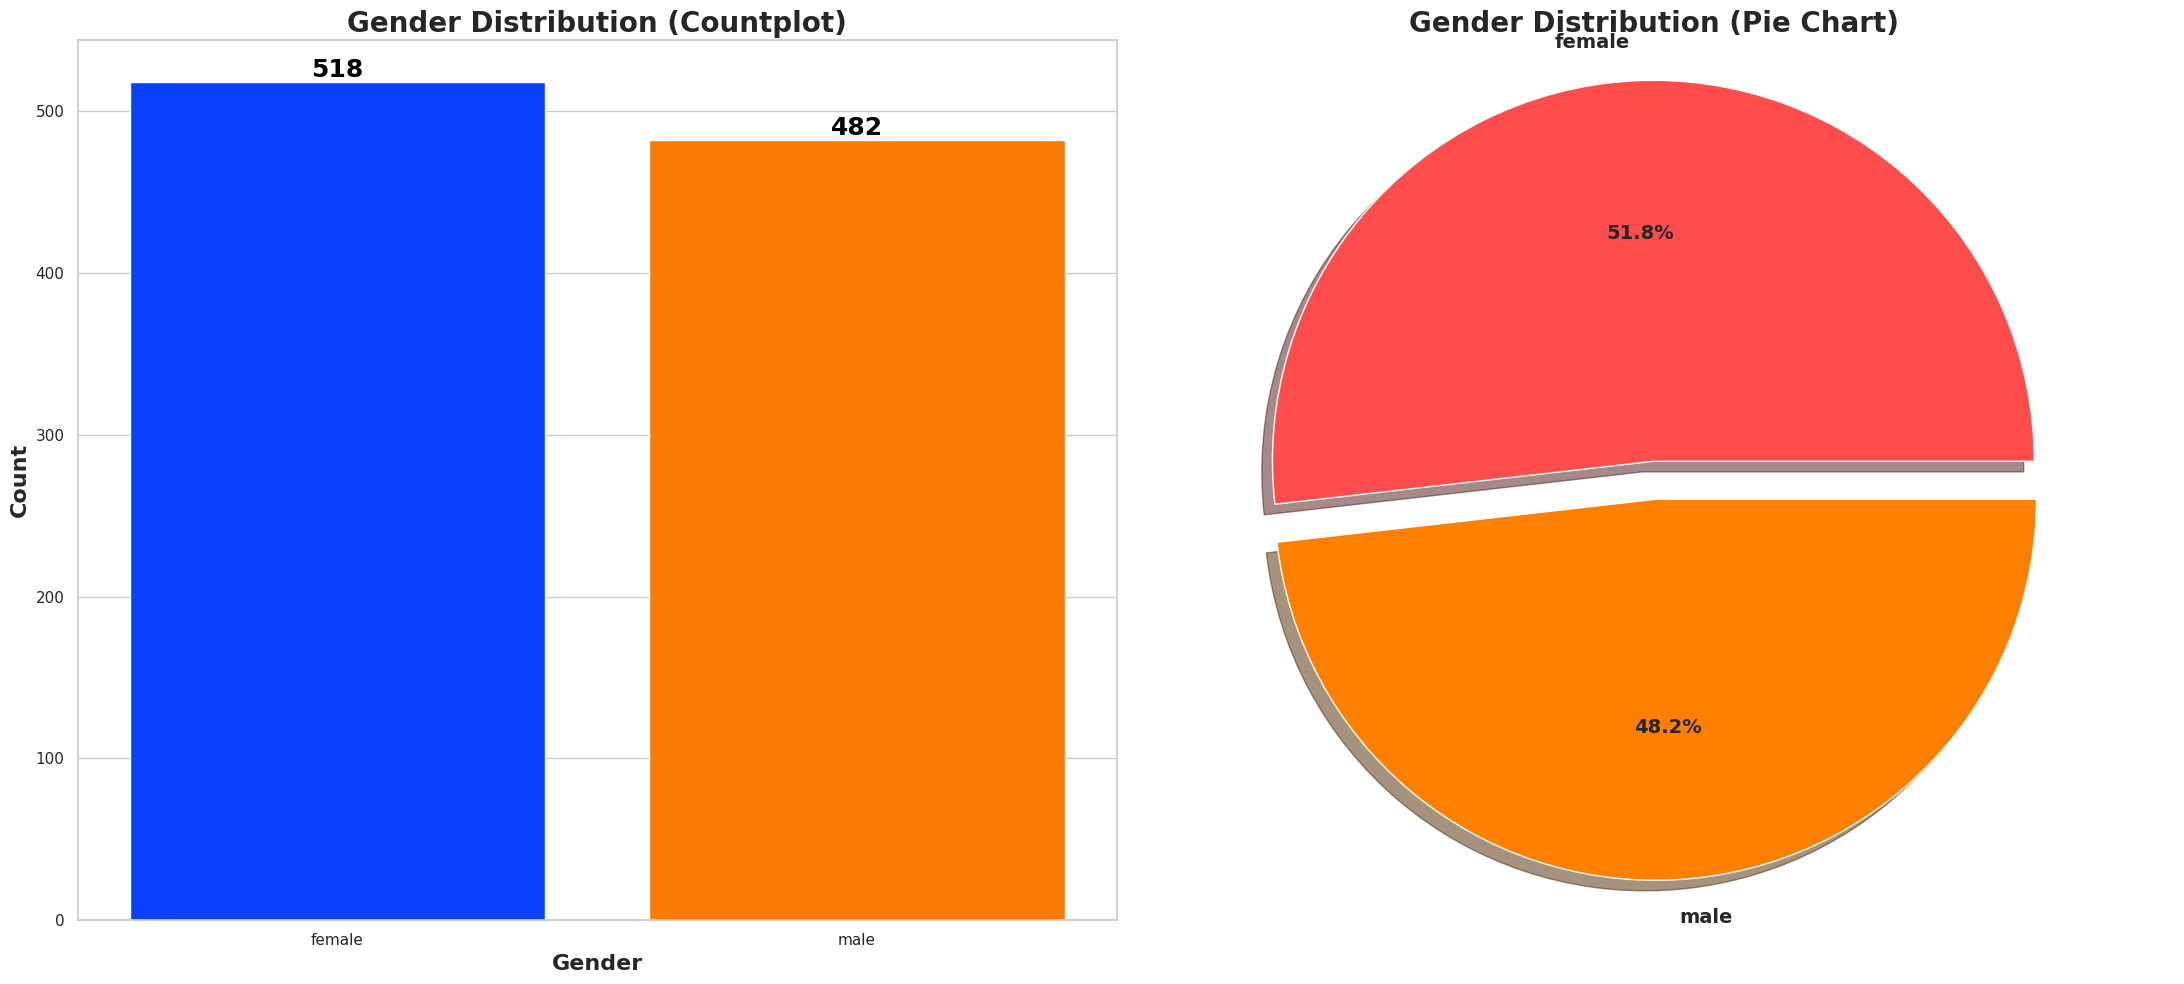

In [51]:
sns.set(style="whitegrid")

# Create figure
fig, ax = plt.subplots(1, 2, figsize=(22, 10))

# -----------------------------
# 1. Bold Countplot (Gender)
# -----------------------------
sns.countplot(
    x='gender',
    data=df,
    palette='bright',
    ax=ax[0],
    saturation=0.95
)

# Add bold labels above bars
for container in ax[0].containers:
    ax[0].bar_label(
        container,
        color='black',
        size=18,
        fontweight='bold'
    )

# Styling
ax[0].set_title('Gender Distribution (Countplot)', fontsize=20, fontweight='bold')
ax[0].set_xlabel('Gender', fontsize=16, fontweight='bold')
ax[0].set_ylabel('Count', fontsize=16, fontweight='bold')

# -----------------------------
# 2. Bold Pie Chart (Gender)
# -----------------------------
gender_counts = df['gender'].value_counts()

ax[1].pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    explode=[0, 0.1],
    shadow=True,
    colors=['#ff4d4d', '#ff8000'],
    textprops={'fontsize': 14, 'fontweight': 'bold'}
)

ax[1].set_title('Gender Distribution (Pie Chart)', fontsize=20, fontweight='bold')
ax[1].axis('equal')  # Keeps circular shape

# -----------------------------
plt.tight_layout()
plt.show()

#### Insights
- Gender has balanced data with female students are 518 (48%) and male students are 482 (52%)

#### BIVARIATE ANALYSIS ( Is gender has any impact on student's performance ? )

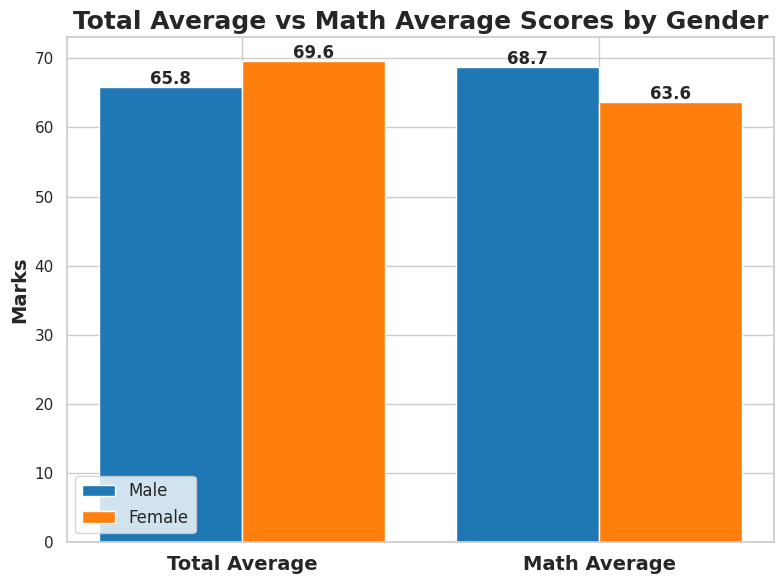

In [53]:
sns.set(style="whitegrid")

# Compute gender-level averages correctly
gender_group = df.groupby('gender').mean(numeric_only=True)

# Extract values using index instead of assuming row order
female_scores = [
    gender_group.loc['female', 'average'],
    gender_group.loc['female', 'math_score']
]

male_scores = [
    gender_group.loc['male', 'average'],
    gender_group.loc['male', 'math_score']
]

# Categories
X = ['Total Average', 'Math Average']
X_axis = np.arange(len(X))

# Plot
plt.figure(figsize=(8, 6))

plt.bar(
    X_axis - 0.2,
    male_scores,
    width=0.4,
    label='Male',
    color='#1f77b4'
)

plt.bar(
    X_axis + 0.2,
    female_scores,
    width=0.4,
    label='Female',
    color='#ff7f0e'
)

# Styling
plt.xticks(X_axis, X, fontsize=14, fontweight='bold')
plt.ylabel("Marks", fontsize=14, fontweight='bold')
plt.title(
    "Total Average vs Math Average Scores by Gender",
    fontsize=18,
    fontweight='bold'
)
plt.legend(fontsize=12)

# Add bar labels
for x, score in zip(X_axis - 0.2, male_scores):
    plt.text(x, score + 0.5, f"{score:.1f}", ha='center', fontsize=12, fontweight='bold')

for x, score in zip(X_axis + 0.2, female_scores):
    plt.text(x, score + 0.5, f"{score:.1f}", ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

#### Insights
- On an average females have a better overall score than men.
- whereas males have scored higher in Maths.

#### 4.4.2 RACE/EHNICITY COLUMN
- How is Group wise distribution ?
- Is Race/Ehnicity has any impact on student's performance ?

#### UNIVARIATE ANALYSIS ( How is Group wise distribution ?)

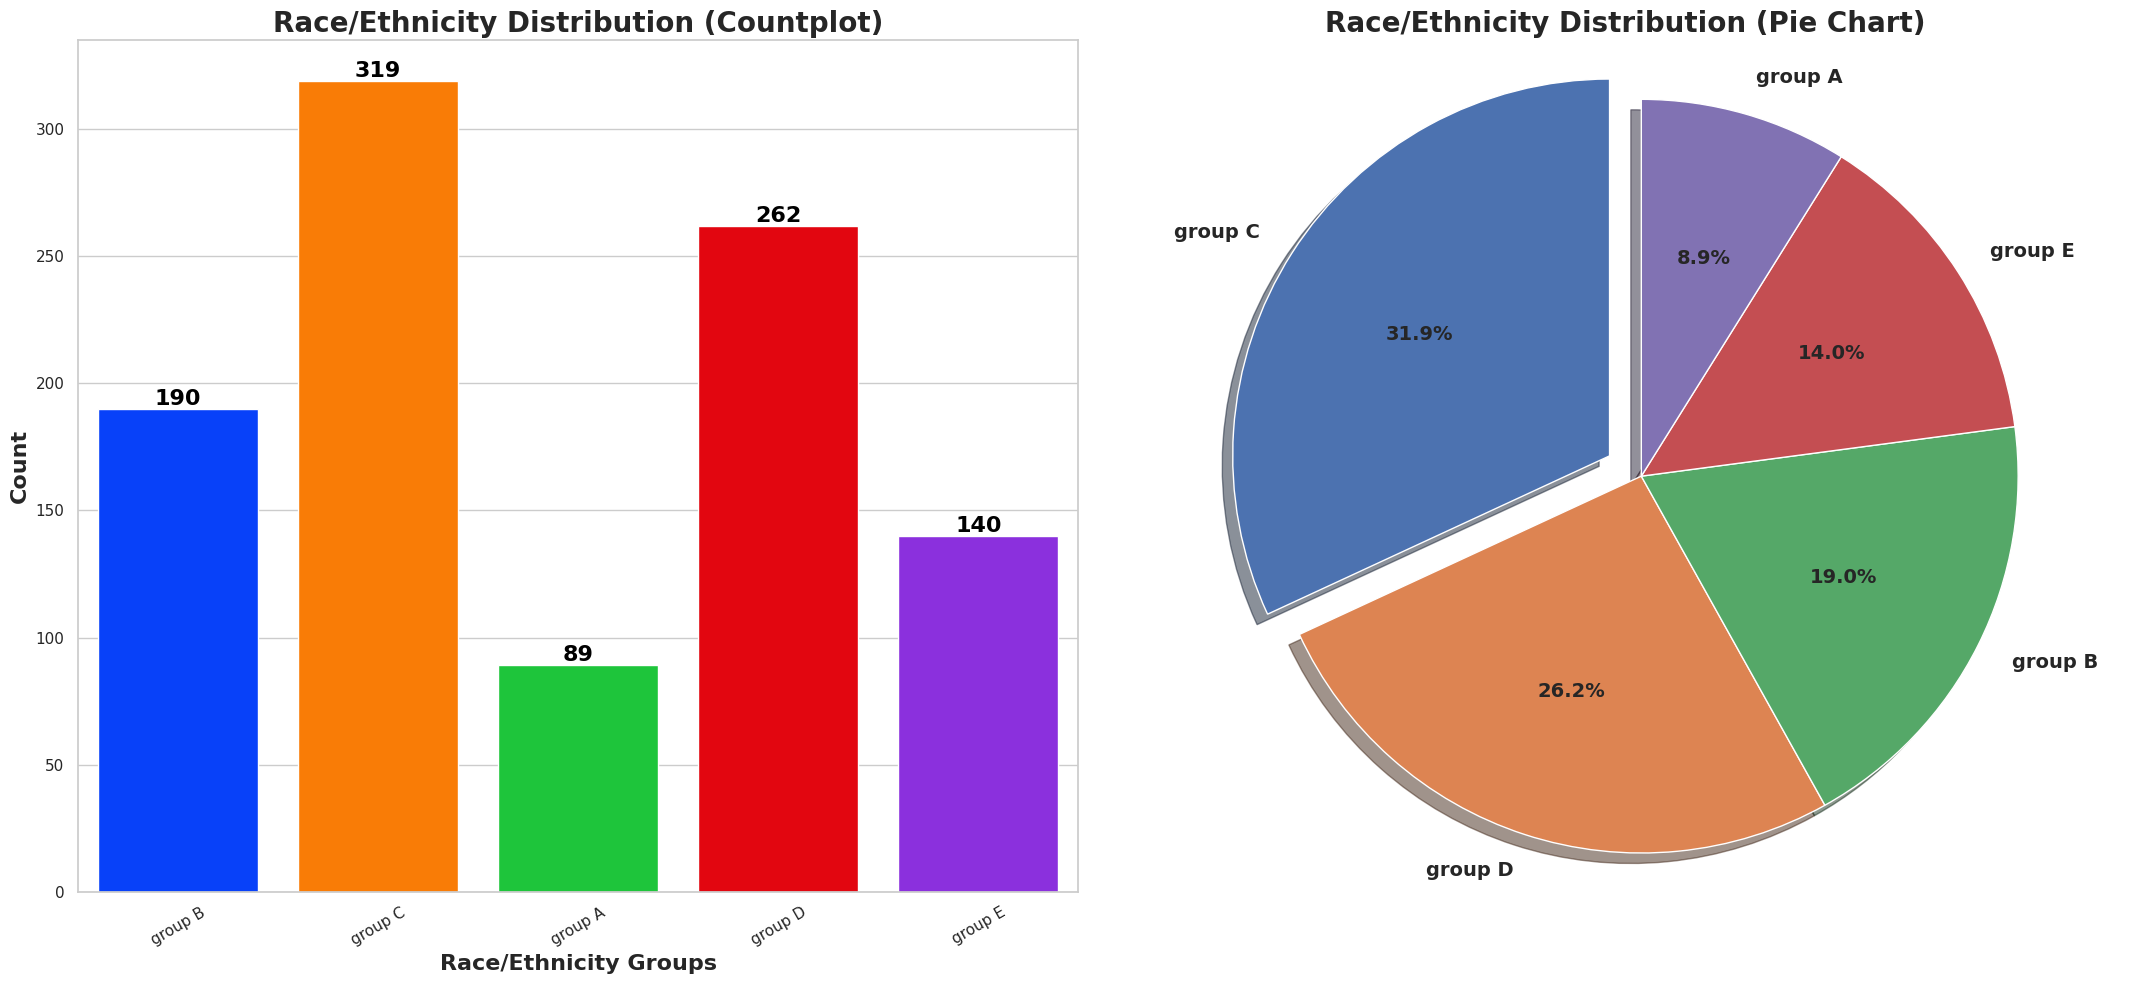

In [55]:
sns.set(style="whitegrid")

# Create figure with two subplots
fig, ax = plt.subplots(1, 2, figsize=(22, 10))

# ----------------------------------
# 1. Bold Countplot (Race/Ethnicity)
# ----------------------------------
sns.countplot(
    x='race_ethnicity',
    data=df,
    palette='bright',
    ax=ax[0],
    saturation=0.95
)

# Add bold bar labels
for container in ax[0].containers:
    ax[0].bar_label(
        container,
        color='black',
        size=16,
        fontweight='bold'
    )

# Styling
ax[0].set_title("Race/Ethnicity Distribution (Countplot)", fontsize=20, fontweight='bold')
ax[0].set_xlabel("Race/Ethnicity Groups", fontsize=16, fontweight='bold')
ax[0].set_ylabel("Count", fontsize=16, fontweight='bold')
ax[0].tick_params(axis='x', labelrotation=30)

# ----------------------------------
# 2. Bold Pie Chart (Race/Ethnicity)
# ----------------------------------
race_counts = df['race_ethnicity'].value_counts()

ax[1].pie(
    race_counts.values,
    labels=race_counts.index,
    explode=[0.1] + [0] * (len(race_counts) - 1),
    autopct='%1.1f%%',
    shadow=True,
    textprops={'fontsize': 14, 'fontweight': 'bold'},
    startangle=90
)

ax[1].set_title("Race/Ethnicity Distribution (Pie Chart)", fontsize=20, fontweight='bold')
ax[1].axis('equal')

# ----------------------------------
plt.tight_layout()
plt.show()

#### Insights
- Most of the student belonging from group C /group D.
- Lowest number of students belong to groupA.

#### BIVARIATE ANALYSIS ( Is Race/Ehnicity has any impact on student's performance ? )

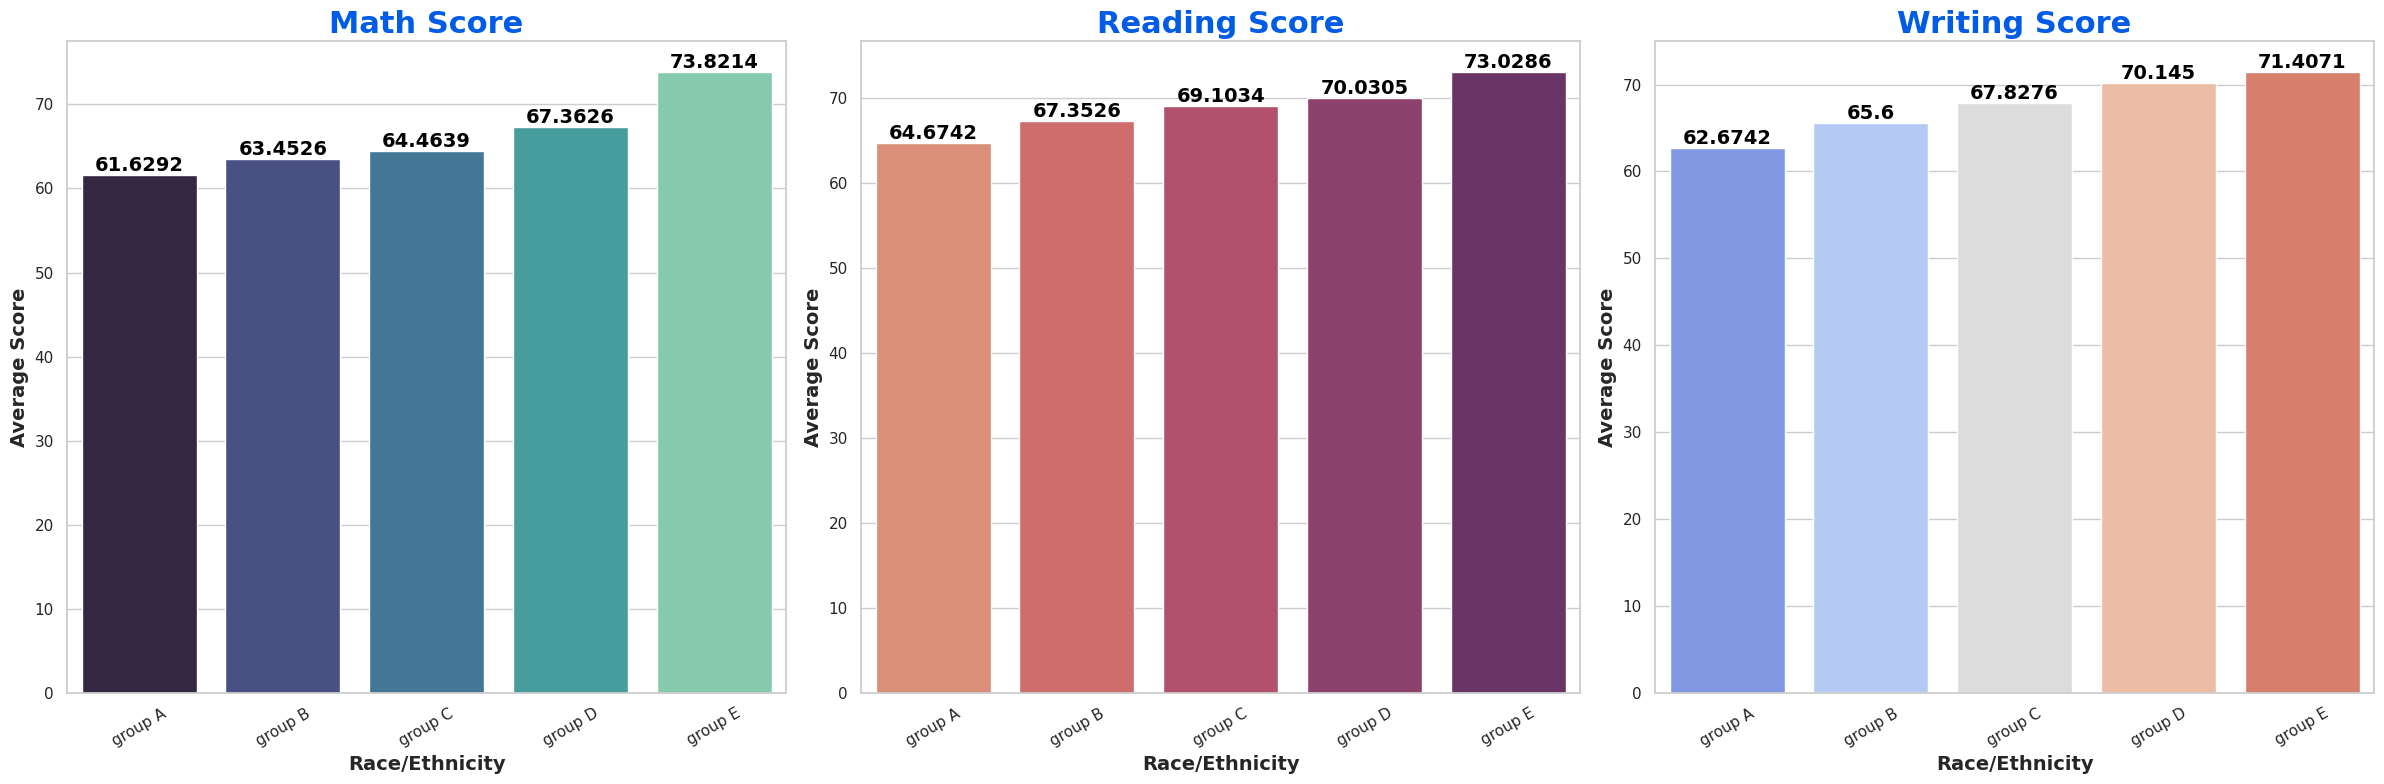

In [56]:
sns.set(style="whitegrid")

# Grouped mean values
group_data = df.groupby('race_ethnicity')[['math_score', 'reading_score', 'writing_score']].mean()

subjects = ['math_score', 'reading_score', 'writing_score']
titles = ['Math Score', 'Reading Score', 'Writing Score']
palettes = ['mako', 'flare', 'coolwarm']

# Create subplots
fig, ax = plt.subplots(1, 3, figsize=(24, 8))

for i, (subject, title, palette) in enumerate(zip(subjects, titles, palettes)):
    sns.barplot(
        x=group_data.index,
        y=group_data[subject],
        palette=palette,
        ax=ax[i]
    )

    ax[i].set_title(title, fontsize=22, fontweight='bold', color='#005ce6')
    ax[i].set_xlabel("Race/Ethnicity", fontsize=14, fontweight='bold')
    ax[i].set_ylabel("Average Score", fontsize=14, fontweight='bold')
    ax[i].tick_params(axis='x', rotation=30)

    # Add bar labels
    for container in ax[i].containers:
        ax[i].bar_label(container, fontsize=14, fontweight='bold', color='black')

plt.tight_layout()
plt.show()


#### Insights
- Group E students have scored the highest marks.
- Group A students have scored the lowest marks.
- Students from a lower Socioeconomic status have a lower avg in all course subjects

#### 4.4.3 PARENTAL LEVEL OF EDUCATION COLUMN
- What is educational background of student's parent ?
- Is parental education has any impact on student's performance ?

#### UNIVARIATE ANALYSIS ( What is educational background of student's parent ? )

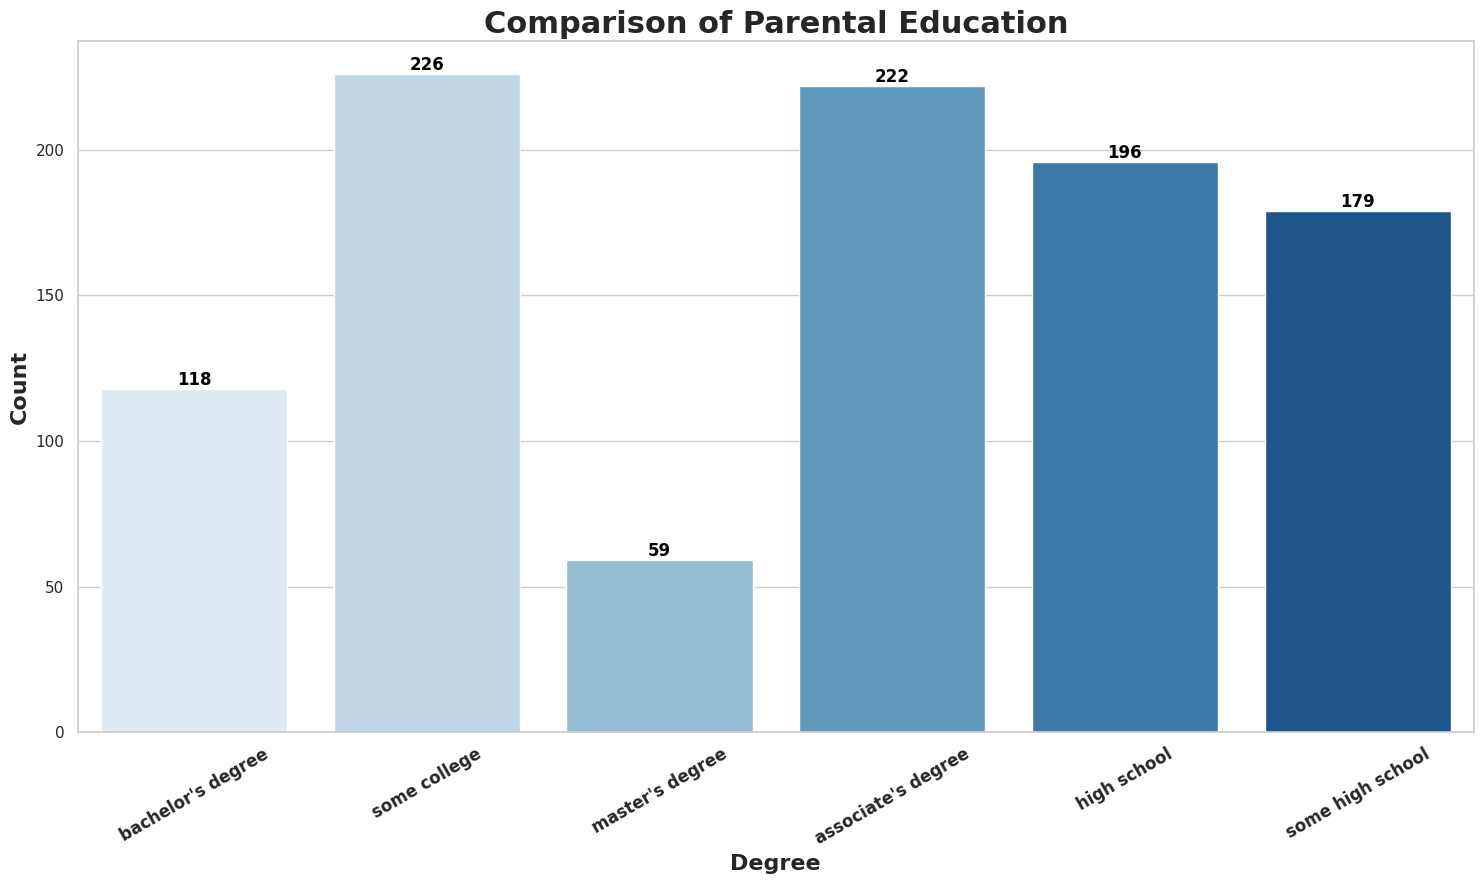

In [57]:
# Styling
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')
sns.set(style="whitegrid")

# Plot
plt.figure(figsize=(15, 9))
sns.countplot(
    x='parental_level_of_education',
    data=df,
    palette='Blues'
)

# Title & Labels
plt.title('Comparison of Parental Education', fontsize=22, fontweight='bold')
plt.xlabel('Degree', fontsize=16, fontweight='bold')
plt.ylabel('Count', fontsize=16, fontweight='bold')

# Rotate x labels for readability
plt.xticks(rotation=30, fontsize=12, fontweight='bold')

# Add bar labels
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=12, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

#### Insights
- Largest number of parents are from some college.

#### BIVARIATE ANALYSIS ( Is parental education has any impact on student's performance ? )

<Figure size 1200x1000 with 0 Axes>

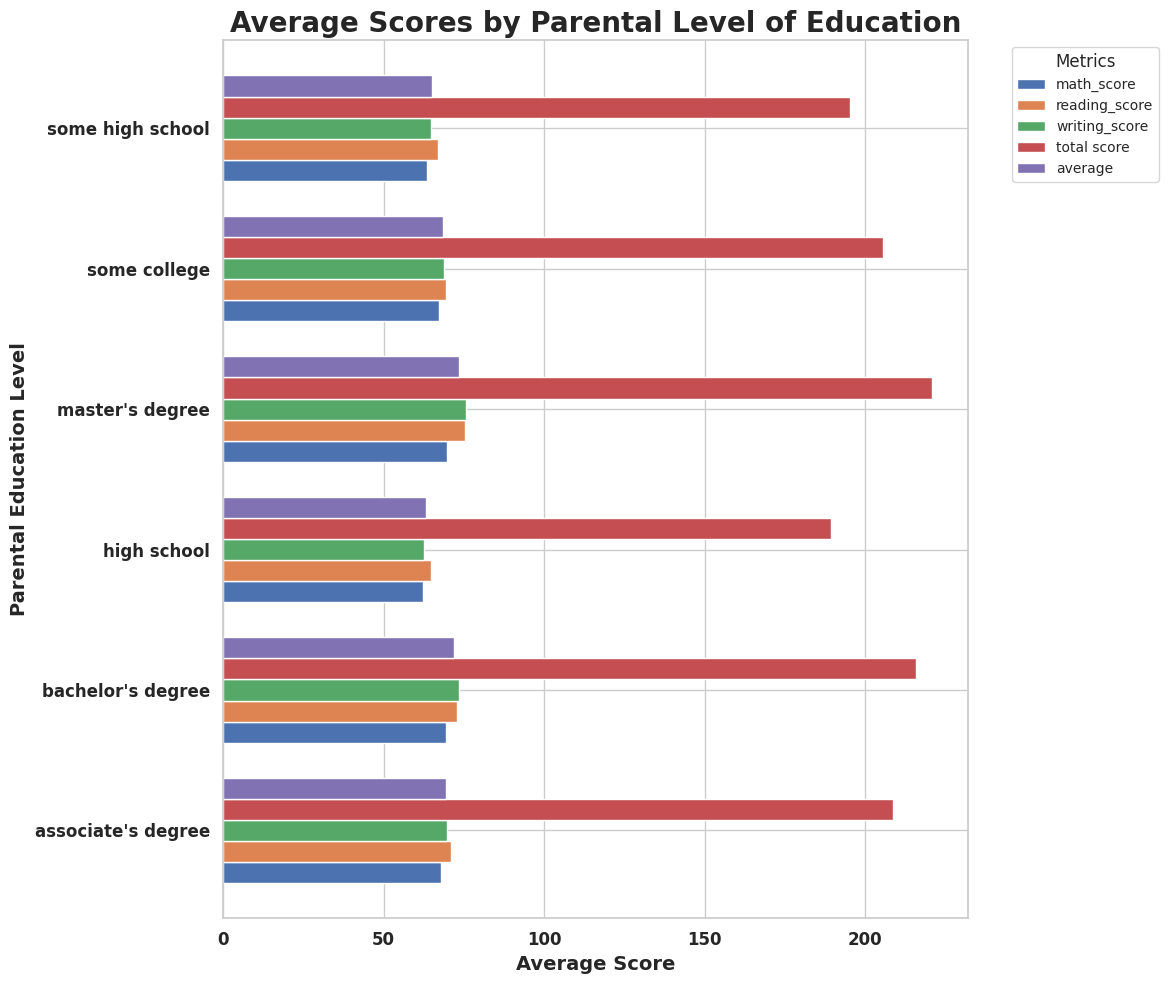

In [58]:
sns.set(style="whitegrid")

group_data = df.groupby('parental_level_of_education').mean(numeric_only=True)

# Plot
plt.figure(figsize=(12, 10))
ax = group_data.plot(
    kind='barh',
    figsize=(12, 10),
    fontsize=12,
    width=0.75
)

# Title and Axis Styling
plt.title(
    'Average Scores by Parental Level of Education',
    fontsize=20,
    fontweight='bold'
)
plt.xlabel('Average Score', fontsize=14, fontweight='bold')
plt.ylabel('Parental Education Level', fontsize=14, fontweight='bold')

# Bold tick labels
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

# Adjust legend
plt.legend(
    title='Metrics',
    title_fontsize=12,
    fontsize=10,
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

#### Insights
- The score of student whose parents possess master and bachelor level education are higher than others.

#### 4.4.4 LUNCH COLUMN
- Which type of lunch is most common amoung students ?
- What is the effect of lunch type on test results?


#### UNIVARIATE ANALYSIS ( Which type of lunch is most common amoung students ? )

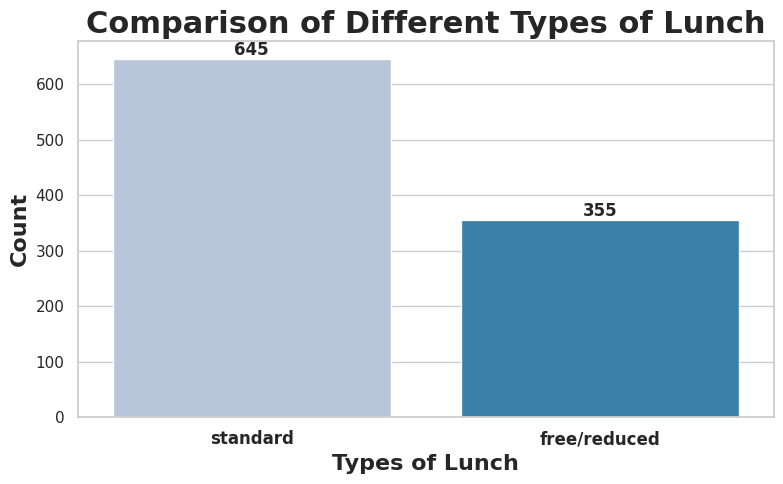

In [73]:
# Styling
plt.rcParams['figure.figsize'] = (15, 9)
sns.set_theme(style="whitegrid")

# Plot
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    x='lunch',
    data=df,
    palette='PuBu'
)

# Title & Axis Labels
plt.title('Comparison of Different Types of Lunch', fontsize=22, fontweight='bold')
plt.xlabel('Types of Lunch', fontsize=16, fontweight='bold')
plt.ylabel('Count', fontsize=16, fontweight='bold')

# Bold X-tick labels
plt.xticks(fontsize=12, fontweight='bold')

# Add labels above bars
for container in ax.containers:
    ax.bar_label(container, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

#### Insights
- Students being served Standard lunch was more than free lunch

#### BIVARIATE ANALYSIS (  Is lunch type intake has any impact on student's performance ? )

<Figure size 1200x600 with 0 Axes>

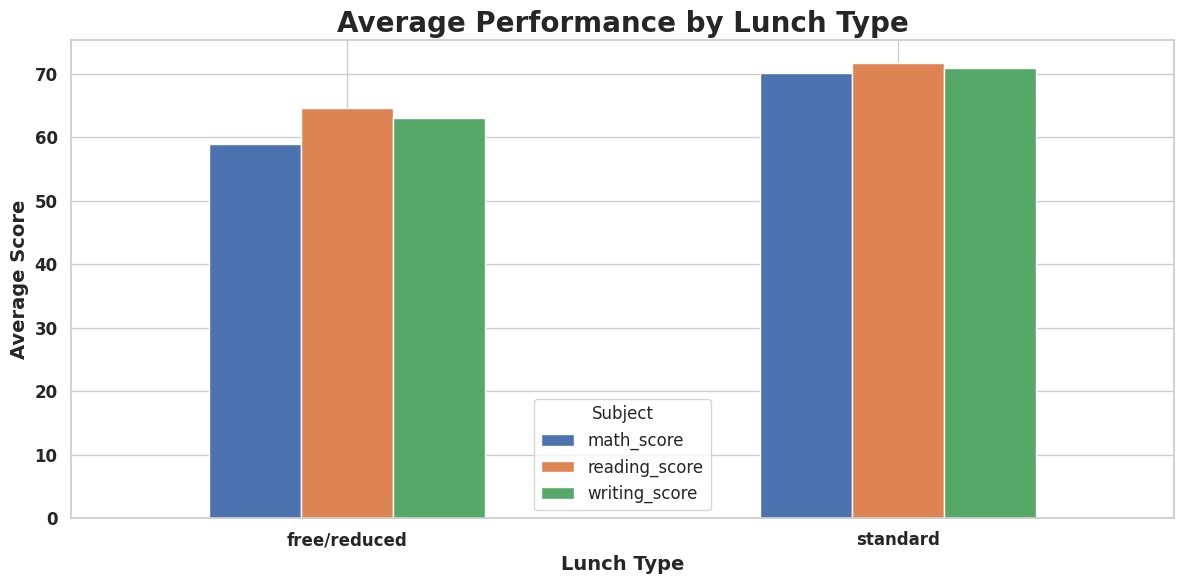

In [64]:
sns.set(style="whitegrid")

# Calculate mean scores grouped by lunch
lunch_group = df.groupby('lunch')[['math_score', 'reading_score', 'writing_score']].mean()

# Plot
plt.figure(figsize=(12, 6))
lunch_group.plot(kind='bar', figsize=(12, 6))

plt.title("Average Performance by Lunch Type", fontsize=20, fontweight='bold')
plt.xlabel("Lunch Type", fontsize=14, fontweight='bold')
plt.ylabel("Average Score", fontsize=14, fontweight='bold')
plt.xticks(fontsize=12, rotation=0, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')
plt.legend(title="Subject", fontsize=12)

plt.tight_layout()
plt.show()

#### Insights
- Students who get Standard Lunch tend to perform better than students who got free/reduced lunch

#### BIVARIATE ANALYSIS ( Is Test prepration course has any impact on student's performance ? )

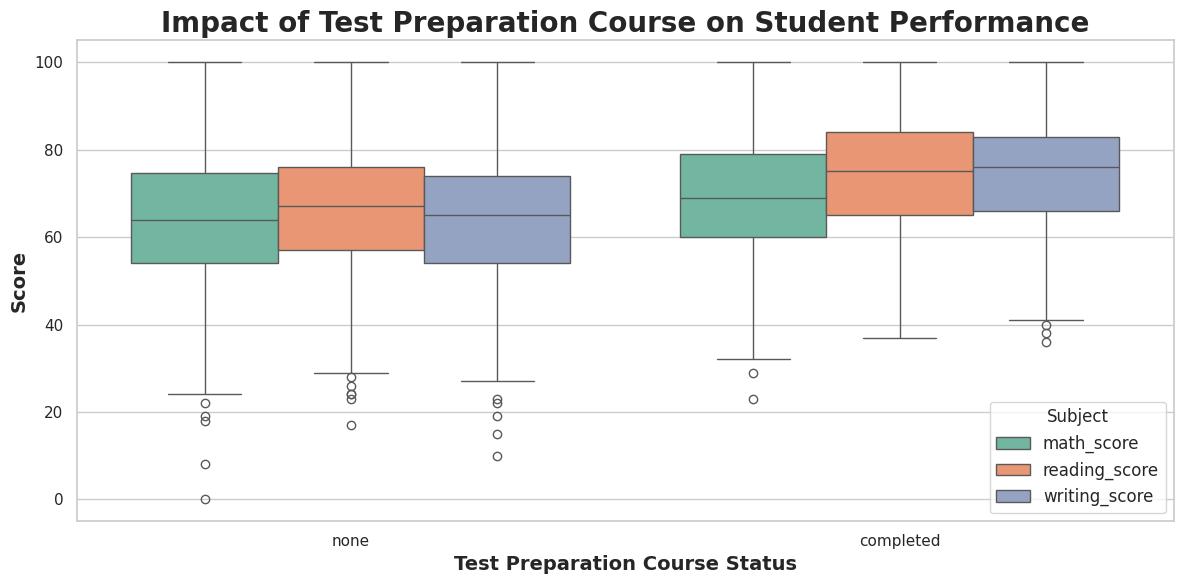

In [69]:
sns.set(style="whitegrid")

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df.melt(id_vars='test_preparation_course',
                 value_vars=['math_score', 'reading_score', 'writing_score'],
                 var_name='Subject',
                 value_name='Score'),
    x='test_preparation_course',
    y='Score',
    hue='Subject',
    palette='Set2'
)

plt.title("Impact of Test Preparation Course on Student Performance", fontsize=20, fontweight='bold')
plt.xlabel("Test Preparation Course Status", fontsize=14, fontweight='bold')
plt.ylabel("Score", fontsize=14, fontweight='bold')
plt.legend(title="Subject", fontsize=12)

plt.tight_layout()
plt.show()

#### Insights  
- Students who have completed the Test Prepration Course have scores higher in all three categories than those who haven't taken the course

#### 4.4.6 CHECKING OUTLIERS

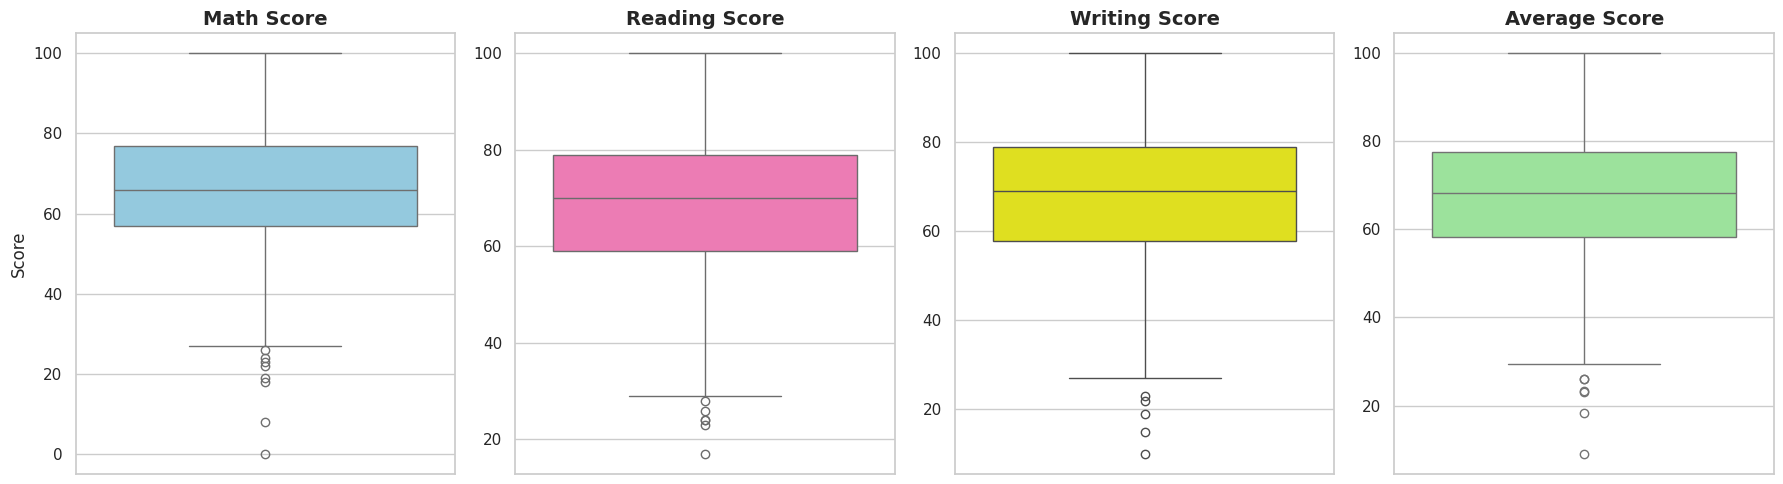

In [70]:
sns.set(style="whitegrid")

plt.figure(figsize=(18, 5))

# 1. Math Score
plt.subplot(1, 4, 1)
sns.boxplot(y=df['math_score'], color='skyblue')
plt.title("Math Score", fontsize=14, fontweight='bold')
plt.ylabel("Score", fontsize=12)

# 2. Reading Score
plt.subplot(1, 4, 2)
sns.boxplot(y=df['reading_score'], color='hotpink')
plt.title("Reading Score", fontsize=14, fontweight='bold')
plt.ylabel("")

# 3. Writing Score
plt.subplot(1, 4, 3)
sns.boxplot(y=df['writing_score'], color='yellow')
plt.title("Writing Score", fontsize=14, fontweight='bold')
plt.ylabel("")

# 4. Average Score
plt.subplot(1, 4, 4)
sns.boxplot(y=df['average'], color='lightgreen')
plt.title("Average Score", fontsize=14, fontweight='bold')
plt.ylabel("")

plt.tight_layout()
plt.show()

#### 4.4.7 MUTIVARIATE ANALYSIS USING PAIRPLOT

<Figure size 1200x800 with 0 Axes>

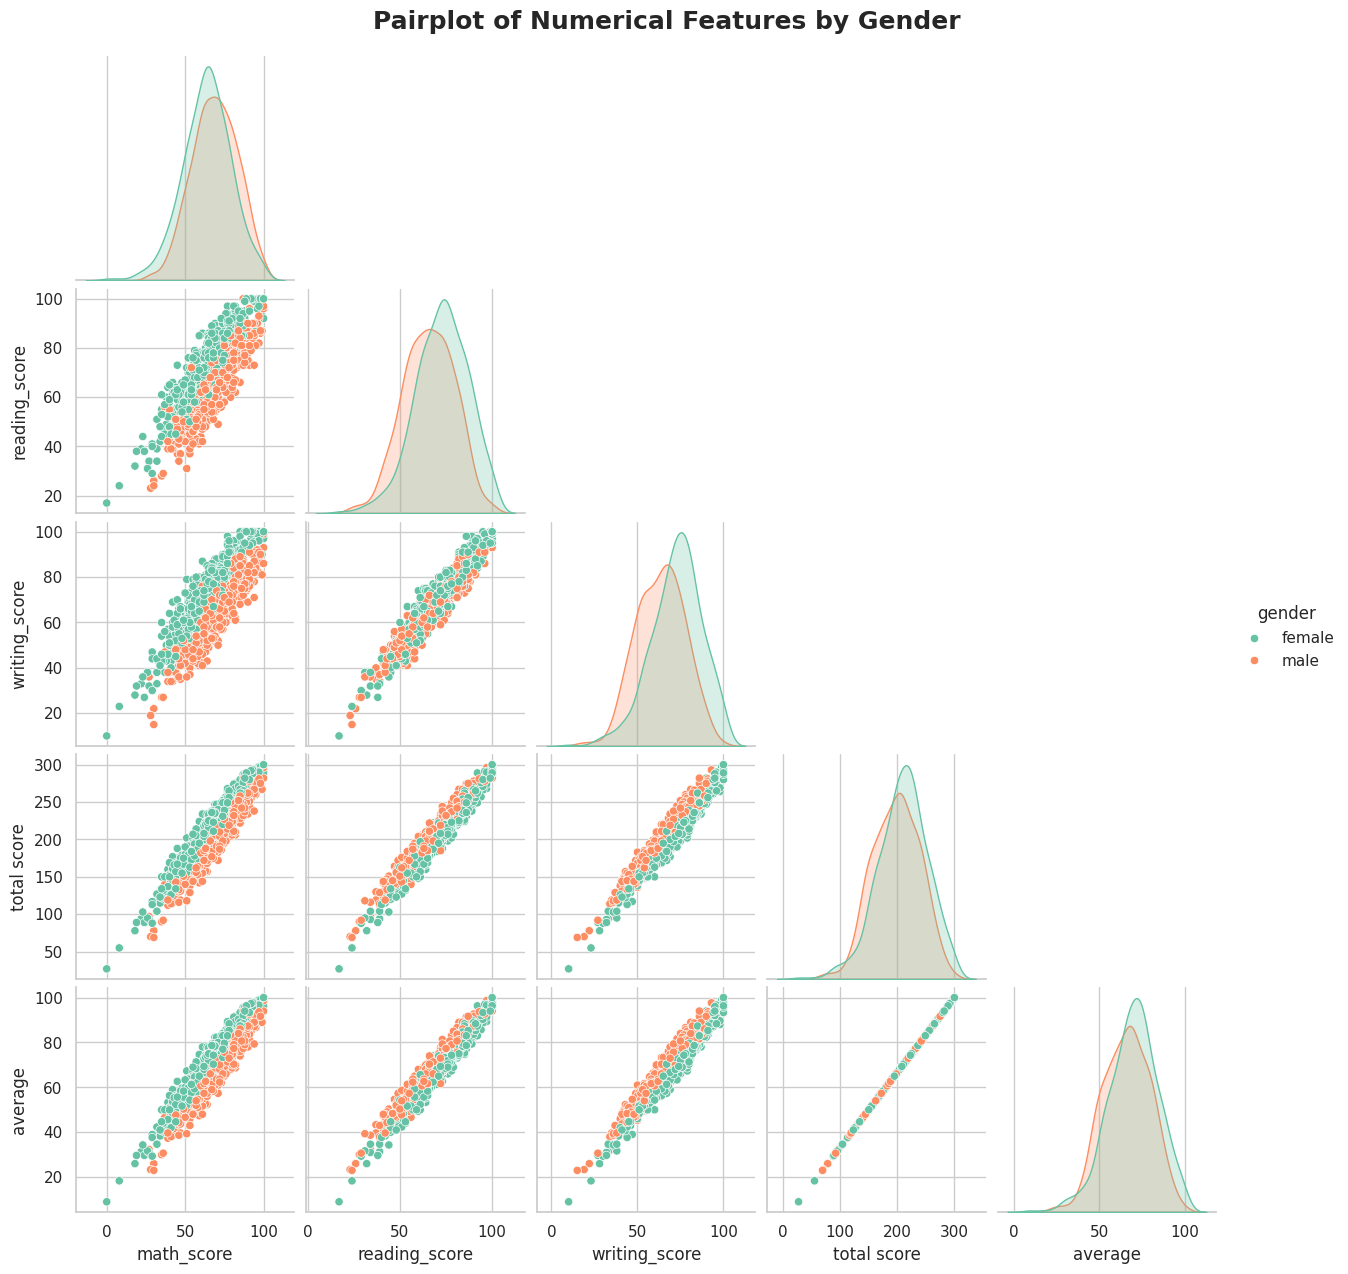

In [72]:
sns.set(style="whitegrid")

plt.figure(figsize=(12, 8))
sns.pairplot(df, hue='gender', corner=True, diag_kind='kde', palette='Set2')

plt.suptitle("Pairplot of Numerical Features by Gender", fontsize=18, fontweight='bold', y=1.02)
plt.show()

#### Insights
- From the above plot it is clear that all the scores increase linearly with each other.

### 5. Conclusions
- Student's Performance is related with lunch, race, parental level education
- Females lead in pass percentage and also are top-scorers
- Student's Performance is not much related with test preparation course
- Finishing preparation course is benefitial.